In [1]:
!pip install pandas transformers torch scikit-learn

In [2]:
import pandas
import transformers
import torch
import sklearn


In [14]:
!pip install pandas transformers torch scikit-learn matplotlib seaborn

In [20]:
!pip install datasets

In [26]:
!pip install kaggle

In [31]:
from google.colab import files
uploaded = files.upload()

Saving amazon_dataset.xlsx to amazon_dataset.xlsx


In [32]:
import pandas as pd

df = pd.read_excel("amazon_dataset.xlsx")

df.head()

,review,sentiment
0,Looks durable Charging is fine tooNo complains...,positive
1,I ordered this cable to connect my phone to An...,positive
2,"Not quite durable and sturdy,https://m.media-a...",neutral
3,"Good product,long wire,Charges good,Nice,I bou...",positive
4,"Bought this instead of original apple, does th...",positive


In [33]:
df

,review,sentiment
0,Looks durable Charging is fine tooNo complains...,positive
1,I ordered this cable to connect my phone to An...,positive
2,"Not quite durable and sturdy,https://m.media-a...",neutral
3,"Good product,long wire,Charges good,Nice,I bou...",positive
4,"Bought this instead of original apple, does th...",positive
...,...,...
1460,"I received product without spanner,Excellent p...",positive
1461,"ok,got everything as mentioned but the measuri...",positive
1462,"plastic but cool body ,u have to find sturdy s...",neutral
1463,I have installed this in my kitchen working fi...,positive


In [34]:
df.columns

Index(['review', 'sentiment'], dtype='object')

In [38]:
df = df.rename(columns={
    df.columns[0]: "label",
    df.columns[1]: "review"
})

In [39]:
def convert(x):
    if x == 0:
        return "Negative"
    elif x == 1:
        return "Neutral"
    else:
        return "Positive"

df.loc[:, "actual_sentiment"] = df["label"].apply(convert)

In [40]:
!pip install transformers torch scikit-learn

In [41]:
from transformers import pipeline

classifier = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment"
)

config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

In [42]:
reviews = df["review"].astype(str).tolist()

results = classifier(reviews, batch_size=32)

In [43]:
label_map = {
    "LABEL_0": "Negative",
    "LABEL_1": "Neutral",
    "LABEL_2": "Positive"
}

predictions = []
confidence = []

for r in results:
    predictions.append(label_map[r["label"]])
    confidence.append(r["score"])

df["predicted_sentiment"] = predictions
df["confidence_score"] = confidence

In [44]:
from sklearn.metrics import accuracy_score, f1_score

print("Accuracy:", accuracy_score(df["actual_sentiment"], df["predicted_sentiment"]))
print("F1 Score:", f1_score(df["actual_sentiment"], df["predicted_sentiment"], average="weighted"))

Accuracy: 0.7723076923076924
F1 Score: 0.8715277777777778


In [45]:
!pip install datasets transformers accelerate -q

In [46]:
from datasets import Dataset

train_df = df[["review", "actual_sentiment"]]

dataset = Dataset.from_pandas(train_df)
dataset

Dataset({
    features: ['review', 'actual_sentiment'],
    num_rows: 1300
})

In [47]:
label2id = {"Negative":0, "Neutral":1, "Positive":2}
id2label = {0:"Negative", 1:"Neutral", 2:"Positive"}

def encode(example):
    example["label"] = label2id[example["actual_sentiment"]]
    return example

dataset = dataset.map(encode)

Map:   0%|          | 0/1300 [00:00<?, ? examples/s]

In [48]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [49]:
def tokenize(batch):
    return tokenizer(batch["review"], truncation=True, padding=True)

dataset = dataset.map(tokenize, batched=True)

Map:   0%|          | 0/1300 [00:00<?, ? examples/s]

In [50]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=1,   # fast training
    per_device_train_batch_size=8
)

In [51]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset
)

trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=163, training_loss=0.04037648183436481, metrics={'train_runtime': 107.3918, 'train_samples_per_second': 12.105, 'train_steps_per_second': 1.518, 'total_flos': 1009047007800.0, 'train_loss': 0.04037648183436481, 'epoch': 1.0})

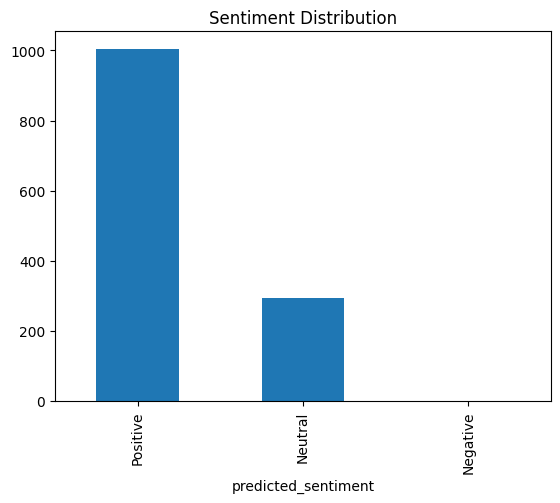

In [56]:
import matplotlib.pyplot as plt

df["predicted_sentiment"].value_counts().plot(kind="bar")

plt.title("Sentiment Distribution")
plt.show()

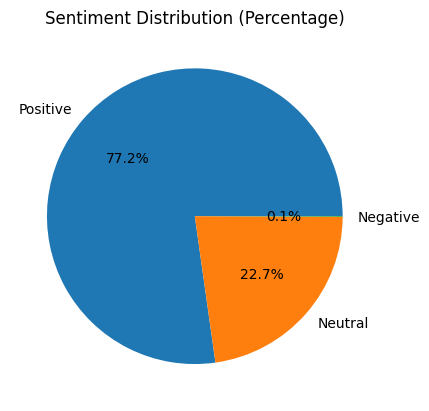

In [61]:
df["predicted_sentiment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Sentiment Distribution (Percentage)")
plt.ylabel("")
plt.show()

In [58]:
aspects = ["price", "delivery", "quality", "service"]

def detect_aspect(text):
    text = text.lower()
    found = []
    for a in aspects:
        if a in text:
            found.append(a)
    return found

df["aspects"] = df["review"].apply(detect_aspect)
df.head()

,label,review,actual_sentiment,predicted_sentiment,confidence_score,aspects
0,Looks durable Charging is fine tooNo complains...,positive,Positive,Positive,0.659935,[]
1,I ordered this cable to connect my phone to An...,positive,Positive,Positive,0.659935,[]
2,"Not quite durable and sturdy,https://m.media-a...",neutral,Positive,Neutral,0.506214,[]
3,"Good product,long wire,Charges good,Nice,I bou...",positive,Positive,Positive,0.659935,[]
4,"Bought this instead of original apple, does th...",positive,Positive,Positive,0.659935,[]


In [59]:
df[["review", "aspects", "predicted_sentiment"]].head(10)

,review,aspects,predicted_sentiment
0,positive,[],Positive
1,positive,[],Positive
2,neutral,[],Neutral
3,positive,[],Positive
4,positive,[],Positive
5,neutral,[],Neutral
6,positive,[],Positive
7,positive,[],Positive
8,positive,[],Positive
9,positive,[],Positive


In [62]:
df.to_csv("final_output.csv", index=False)

In [64]:
from google.colab import files
files.download("final_output.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>